# Notebook 2: Teacher Model (Thick-File XGBoost)
Trains on users with full credit history. Three-way split ensures calibration is not overfit. Outputs soft probabilities for knowledge distillation.

In [1]:
import pandas as pd
import numpy as np
import json, pickle, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, average_precision_score

thick = pd.read_parquet('thick_file_dataset.parquet')
with open('feature_sets.json') as f:
    fs = json.load(f)
TEACHER_FEATURES = fs['teacher']

# Teacher trains ONLY on thick-file users
train_df = thick[thick['IS_THIN_FILE'] == 0].reset_index(drop=True)
print(f'Teacher set: {train_df.shape} | default rate: {train_df["TARGET"].mean():.3f}')

Teacher set: (305271, 59) | default rate: 0.081


## 1. Three-Way Split
train → fit XGBoost, cal → fit isotonic calibrator, val → evaluation only.
Never fit and evaluate on the same set.

In [2]:
X = train_df[TEACHER_FEATURES]
y = train_df['TARGET']

# First split: hold out val
X_trainval, X_val, y_trainval, y_val = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
# Second split: separate train from calibration set
X_train, X_cal, y_train, y_cal = train_test_split(
    X_trainval, y_trainval, test_size=0.15, stratify=y_trainval, random_state=42
)

print(f'Train: {X_train.shape} | Cal: {X_cal.shape} | Val: {X_val.shape}')

Train: (220558, 54) | Cal: (38922, 54) | Val: (45791, 54)


## 2. XGBoost Teacher

In [3]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()

# ── Monotonic constraints ──────────────────────────────────────────────
# +1 = feature MUST push risk UP as it increases (financially grounded)
#  0 = unconstrained (demographics — still learned, but not forced)
# -1 = feature MUST push risk DOWN as it increases
#
# We constrain the key financial ratios so the model is forced to respect
# economic logic. This fixes demographic-dominance because demographics
# can't 'explain away' what the constrained financial features are forced
# to capture.
#
# Build the constraint vector aligned with TEACHER_FEATURES order.
MONOTONE_MAP = {
    # Financial ratios — risk increases as value increases
    'DEBT_TO_INCOME':      1,   # more debt vs income → riskier
    'ANNUITY_TO_INCOME':   1,   # bigger repayment share → riskier
    'CREDIT_TO_GOODS':     1,   # credit inflated vs goods → riskier
    # Employment / stability — risk decreases as these grow
    'EMPLOYED_YEARS':     -1,   # longer tenure → safer
    'AGE_YEARS':          -1,   # older → safer (up to a point; XGB handles plateau)
    # Everything else unconstrained
}
monotone_constraints = tuple(
    MONOTONE_MAP.get(f, 0) for f in TEACHER_FEATURES
)

xgb_teacher = XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    colsample_bylevel     = 0.8,   # extra regularisation → dampens demographic shortcuts
    scale_pos_weight      = neg / pos,
    reg_alpha             = 0.5,   # increased L1 → sparsity, fewer demographic proxies
    reg_lambda            = 2.0,   # increased L2 → smoother, less overfit on demographics
    monotone_constraints  = monotone_constraints,
    eval_metric           = 'auc',
    early_stopping_rounds = 30,
    random_state          = 42,
    tree_method           = 'hist',
    verbosity             = 0,
)

xgb_teacher.fit(
    X_train, y_train,
    eval_set=[(X_cal, y_cal)],
    verbose=100
)

val_preds = xgb_teacher.predict_proba(X_val)[:, 1]
print(f'\nTeacher Val ROC-AUC : {roc_auc_score(y_val, val_preds):.4f}')
print(f'Teacher Val PR-AUC  : {average_precision_score(y_val, val_preds):.4f}')


[0]	validation_0-auc:0.63387
[100]	validation_0-auc:0.71428
[200]	validation_0-auc:0.72144
[300]	validation_0-auc:0.72278
[400]	validation_0-auc:0.72406
[499]	validation_0-auc:0.72451

Teacher Val ROC-AUC : 0.7348
Teacher Val PR-AUC  : 0.2163


## 3. Isotonic Calibration
`cv='prefit'`: base model already fitted, only learn the isotonic mapping.
Fit on X_cal, evaluate on X_val (held-out).

In [4]:
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Get raw teacher probabilities on calibration set
raw_cal_probs = xgb_teacher.predict_proba(X_cal)[:, 1]

# 2. Fit isotonic calibrator (NO re-training of XGBoost)
iso_calibrator = IsotonicRegression(out_of_bounds='clip')
iso_calibrator.fit(raw_cal_probs, y_cal)

# 3. Evaluate on validation set
raw_val_probs = xgb_teacher.predict_proba(X_val)[:, 1]
cal_preds = iso_calibrator.transform(raw_val_probs)

print(f'Calibrated Val ROC-AUC : {roc_auc_score(y_val, cal_preds):.4f}')
print(f'Mean predicted prob    : {cal_preds.mean():.4f}')
print(f'Actual default rate    : {y_val.mean():.4f}')

Calibrated Val ROC-AUC : 0.7341
Mean predicted prob    : 0.0813
Actual default rate    : 0.0808


## 4. Generate Soft Labels for ALL Users
Teacher scores every row including thin-file users (their history cols = 0 after imputation).
These soft probabilities are the student's training target.

In [5]:
# Score the ENTIRE thick dataset (thick + thin file users)
# For thin-file users: history cols are 0 (imputed), teacher still produces a score
# This score = what a full-data model WOULD predict given similar demographics

all_X = thick[TEACHER_FEATURES]
# Get raw probs from teacher
raw_all_probs = xgb_teacher.predict_proba(all_X)[:, 1]

# Pass through calibrator
thick['SOFT_LABEL'] = iso_calibrator.transform(raw_all_probs)

print('Soft label distribution:')
print(thick['SOFT_LABEL'].describe().round(4))
print()
print('Thin-file soft labels vs thick-file soft labels:')
print(thick.groupby('IS_THIN_FILE')['SOFT_LABEL'].describe().round(4))

Soft label distribution:
count    307511.0000
mean          0.0817
std           0.0720
min           0.0000
25%           0.0413
50%           0.0602
75%           0.1008
max           1.0000
Name: SOFT_LABEL, dtype: float64

Thin-file soft labels vs thick-file soft labels:
                 count    mean     std  min     25%     50%     75%    max
IS_THIN_FILE                                                              
0             305271.0  0.0817  0.0721  0.0  0.0377  0.0602  0.1008  1.000
1               2240.0  0.0785  0.0538  0.0  0.0420  0.0602  0.1030  0.325


## 5. Feature Importance

Top 20 Teacher Features:
NAME_EDUCATION_TYPE     0.0706
REGION_RATING_CLIENT    0.0474
NAME_INCOME_TYPE        0.0387
AGE_YEARS               0.0374
CREDIT_TO_GOODS         0.0363
cc_avg_utilization      0.0361
EMPLOYED_YEARS          0.0351
prev_refused_count      0.0331
inst_late_rate          0.0307
bureau_active_count     0.0265
FLAG_OWN_CAR            0.0235
prev_approval_rate      0.0206
AMT_GOODS_PRICE         0.0203
bureau_total_debt       0.0183
inst_count              0.0182
bureau_count            0.0175
cc_months_active        0.0173
bureau_avg_credit       0.0170
OCCUPATION_TYPE         0.0167
AMT_ANNUITY             0.0167


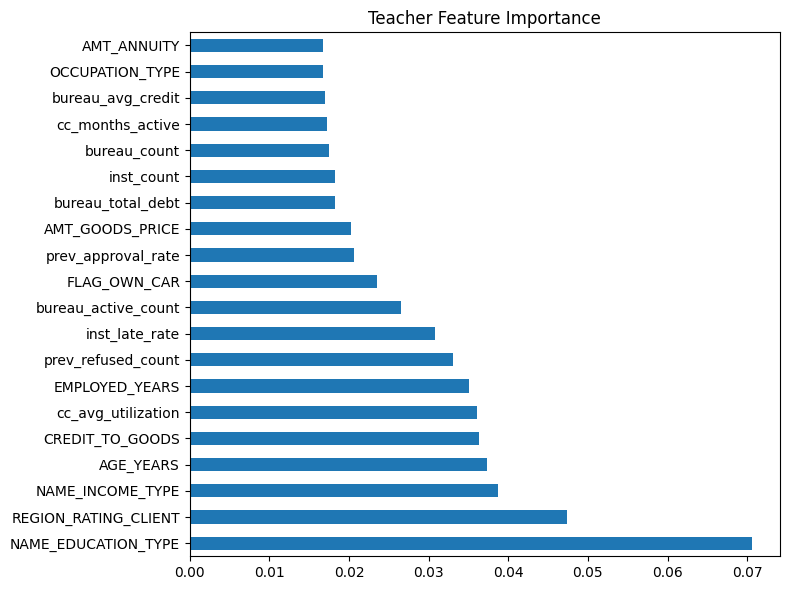

In [6]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    xgb_teacher.feature_importances_, index=TEACHER_FEATURES
).sort_values(ascending=False)

print('Top 20 Teacher Features:')
print(feat_imp.head(20).round(4).to_string())

feat_imp.head(20).plot(kind='barh', figsize=(8,6), title='Teacher Feature Importance')
plt.tight_layout()
plt.savefig('teacher_feature_importance.png', dpi=120)
plt.show()

## 6. Save

In [7]:
import pickle

# Save BOTH teacher model + calibrator together
with open('teacher_model.pkl', 'wb') as f:
    pickle.dump({
        "model": xgb_teacher,
        "calibrator": iso_calibrator
    }, f)

# Save dataset with soft labels
thick.to_parquet('thick_with_soft_labels.parquet', index=False)

print('Saved: teacher_model.pkl (model + calibrator)')
print('Saved: thick_with_soft_labels.parquet')
print()
print('Ready for Notebook 3: Student Model Training')

Saved: teacher_model.pkl (model + calibrator)
Saved: thick_with_soft_labels.parquet

Ready for Notebook 3: Student Model Training
